# PDF Validation Sample Selection

Goal: select representative multi-asset funds suitable for checking **PDF → holdings dataset** extraction quality.

**Core idea:** first build a comparable pool of normal multi-asset funds, then compare completeness within that pool.
100% completeness does not mean a good PDF validation sample.

Method summary:
1. **Align reporting date** — use only the `As At Date` matching the PDF (default `31-Mar-26`)
2. **Exclude non-investment items** — Cash / Other Assets / Liabilities are not scored
3. **Require real investments ∈ [6, 30]** — exclude co-investments / single-company vehicles; keep manual review tractable
4. **Score completeness only on real investment rows** (7 key fields)
5. **Diverse sampling** — High 6 / Low 6 / Random 5; avoid same manager, homogeneous strategy, all wind-downs

### 1. Imports and parameters

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Tunable parameters ---
LINK = ''
TARGET_AS_AT_DATE = '31-Mar-26'   # reporting date aligned with PDF
MIN_INVESTMENTS = 6               # min real investments (>5)
MAX_INVESTMENTS = 30              # max for manageable manual review
N_HIGH = 6
N_LOW = 6
N_RANDOM = 5
RANDOM_SEED = 42
SIZE_RATIO_MAX = 10.0             # size diversity: candidate vs selected median <= 10x
WIND_DOWN_RATIO = 0.30            # current real investments < hist peak * ratio → wind-down
SHORTLIST_FACTOR = 5              # shortlist size = n * factor before soft diversity

MANDATORY = [
    'Deal Status', 'Current Cost', 'Unrealized Value',
    'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value',
]

# Force ID columns as strings to avoid scientific-notation corruption
ID_DTYPES = {
    'Investment Manager Allocator ID': 'string',
    'Fund Allocator ID': 'string',
    'Source Asset ID': 'string',
    'Instrument ID': 'string',
    'Allocator Asset Allocator ID': 'string',
}

print(f'Target date : {TARGET_AS_AT_DATE}')
print(f'Investment range : [{MIN_INVESTMENTS}, {MAX_INVESTMENTS}]')
print(f'Sample sizes : High={N_HIGH}, Low={N_LOW}, Random={N_RANDOM}')
print(f'Scored fields : {MANDATORY}')

Target date : 31-Mar-26
Investment range : [6, 30]
Sample sizes : High=6, Low=6, Random=5
Scored fields : ['Deal Status', 'Current Cost', 'Unrealized Value', 'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value']


### 2. Load and clean data

In [2]:
df = pd.read_csv(
    LINK + 'holdings_anonymized.csv',
    low_memory=False,
    dtype={k: v for k, v in ID_DTYPES.items()},
)
df_clean = df.dropna(axis=1, how='all').copy()

df_clean['As At Date'] = pd.to_datetime(
    df_clean['As At Date'], format='%d-%b-%y', errors='coerce'
)
target_dt = pd.to_datetime(TARGET_AS_AT_DATE, format='%d-%b-%y')

print(f'Raw shape      : {df.shape}')
print(f'After drop-all : {df_clean.shape}')
print(f'Dates available: {sorted(df_clean["As At Date"].dropna().dt.strftime("%d-%b-%y").unique())}')
print(f'Funds (all)    : {df_clean["Fund Allocator ID"].nunique()}')
print(f'Funds on target: {df_clean.loc[df_clean["As At Date"] == target_dt, "Fund Allocator ID"].nunique()}')

Raw shape      : (58160, 837)
After drop-all : (58160, 588)
Dates available: ['30-Jun-25', '30-Sep-25', '31-Dec-24', '31-Dec-25', '31-Mar-25', '31-Mar-26']
Funds (all)    : 385
Funds on target: 320


### 3. Exclude non-investment items; keep real investment rows

Exclude `Source Asset` values such as:
- Non-Investment Assets – Cash
- Non-Investment Assets – Other Assets
- Non-Investment Liabilities …

Completeness and investment counts are computed only on real portfolio-company rows.

In [3]:
# Cover common spelling variants (Non-Investment / Non-Investments / Non-investments / Non-Investmentsa)
NON_INVESTMENT_PATTERN = re.compile(
    r'(?i)^(?:Net\s+)?Non[- ]?Investments?a?\s+'
    r'(?:Assets|Liabilities)'
)

def is_real_investment(source_asset) -> bool:
    return not bool(NON_INVESTMENT_PATTERN.match(str(source_asset)))


def investment_key(frame: pd.DataFrame) -> pd.Series:
    """Prefer Source Asset ID; fall back to Source Asset name."""
    if 'Source Asset ID' in frame.columns:
        key = frame['Source Asset ID'].astype(str)
        missing = frame['Source Asset ID'].isna()
        key = key.where(~missing, frame['Source Asset'].astype(str))
        return key
    return frame['Source Asset'].astype(str)


df_clean['is_real_investment'] = df_clean['Source Asset'].map(is_real_investment)
df_clean['investment_key'] = investment_key(df_clean)

n_non = (~df_clean['is_real_investment']).sum()
n_real = df_clean['is_real_investment'].sum()
print(f'Real investment rows     : {n_real:,}')
print(f'Non-investment rows      : {n_non:,}')
print('\nNon-investment Source Asset (top 10):')
print(
    df_clean.loc[~df_clean['is_real_investment'], 'Source Asset']
    .value_counts()
    .head(10)
    .to_string()
)

Real investment rows     : 52,644
Non-investment rows      : 5,516

Non-investment Source Asset (top 10):
Source Asset
Non-Investment Assets - Cash                                    1802
Non-Investment Liabilities - Other Liabilities                  1795
Non-Investment Assets - Other Assets                            1531
Non-Investment Liabilities - Subscription Line of Credit         276
Non-Investment Assets - Other assets                              24
Net Non-Investment Assets from Canyon Laurell II Master Fund       6
Non-Investmentsa Assets - Cash and cash equivalents                6
Non-Investmentsa Liabilities- Other Liabilities                    6
Non-Investment Assets - Cash and cash equivalents                  6
Non-Investment Assets - Cash.                                      6


### 4. Build eligible fund pool (aligned date + real-investment count filter)

In [4]:
df_target = df_clean[df_clean['As At Date'] == target_dt].copy()
df_target_real = df_target[df_target['is_real_investment']].copy()

funds_on_target = df_target['Fund Allocator ID'].nunique()
funds_with_real = df_target_real['Fund Allocator ID'].nunique()

# Per-fund counts on target date
n_real_by_fund = (
    df_target_real.groupby('Fund Allocator ID')['investment_key']
    .nunique()
    .rename('n_real_investments')
)
n_total_rows = (
    df_target.groupby('Fund Allocator ID').size()
    .rename('n_total_rows')
)
n_real_rows = (
    df_target_real.groupby('Fund Allocator ID').size()
    .rename('n_real_rows')
)

# Manager / strategy / size proxies from real rows
manager = (
    df_target_real.groupby('Fund Allocator ID')['Investment Manager Allocator ID']
    .agg(lambda s: s.mode().iloc[0] if len(s.mode()) else s.iloc[0])
    .rename('Investment Manager Allocator ID')
)
toi = (
    df_target_real.groupby('Fund Allocator ID')['Type of Investment']
    .agg(lambda s: s.mode().iloc[0] if len(s.dropna().mode()) else (s.dropna().iloc[0] if s.notna().any() else np.nan))
    .rename('Type of Investment')
)
portfolio_tv = (
    df_target_real.groupby('Fund Allocator ID')['Total Value']
    .sum(min_count=1)
    .rename('portfolio_total_value')
)

# Historical peak real-investment count (for wind-down flag)
hist_real = df_clean[df_clean['is_real_investment']].copy()
hist_peak = (
    hist_real.groupby(['Fund Allocator ID', 'As At Date'])['investment_key']
    .nunique()
    .groupby('Fund Allocator ID')
    .max()
    .rename('hist_max_real_investments')
)

fund_stats = (
    pd.concat([n_real_by_fund, n_total_rows, n_real_rows, manager, toi, portfolio_tv, hist_peak], axis=1)
    .reset_index()
)
fund_stats['n_real_investments'] = fund_stats['n_real_investments'].fillna(0).astype(int)
fund_stats['n_total_rows'] = fund_stats['n_total_rows'].fillna(0).astype(int)
fund_stats['n_real_rows'] = fund_stats['n_real_rows'].fillna(0).astype(int)
fund_stats['hist_max_real_investments'] = fund_stats['hist_max_real_investments'].fillna(0).astype(int)
fund_stats['wind_down_flag'] = (
    (fund_stats['hist_max_real_investments'] > 0)
    & (fund_stats['n_real_investments'] < fund_stats['hist_max_real_investments'] * WIND_DOWN_RATIO)
)

# Eligibility funnel
has_target = fund_stats['Fund Allocator ID'].isin(df_target['Fund Allocator ID'])
has_real = fund_stats['n_real_rows'] >= 1
in_range = (
    (fund_stats['n_real_investments'] >= MIN_INVESTMENTS)
    & (fund_stats['n_real_investments'] <= MAX_INVESTMENTS)
)

eligible_funds = fund_stats.loc[has_target & has_real & in_range].copy()

print('--- Eligibility funnel ---')
print(f'Funds with data on {TARGET_AS_AT_DATE}     : {funds_on_target}')
print(f'  with >=1 real investment row            : {funds_with_real}')
print(f'  with n_real in [{MIN_INVESTMENTS}, {MAX_INVESTMENTS}] : {len(eligible_funds)}')
print(f'  excluded: too few (<{MIN_INVESTMENTS})  : {int((has_target & has_real & (fund_stats["n_real_investments"] < MIN_INVESTMENTS)).sum())}')
print(f'  excluded: too many (>{MAX_INVESTMENTS}) : {int((has_target & has_real & (fund_stats["n_real_investments"] > MAX_INVESTMENTS)).sum())}')
print(f'  wind-down flagged among eligible        : {int(eligible_funds["wind_down_flag"].sum())}')
print('\neligible_funds head:')
display(eligible_funds.sort_values('n_real_investments', ascending=False).head(10))

--- Eligibility funnel ---
Funds with data on 31-Mar-26     : 320
  with >=1 real investment row            : 318
  with n_real in [6, 30] : 152
  excluded: too few (<6)  : 62
  excluded: too many (>30) : 104
  wind-down flagged among eligible        : 0

eligible_funds head:


,Fund Allocator ID,n_real_investments,n_total_rows,n_real_rows,Investment Manager Allocator ID,Type of Investment,portfolio_total_value,hist_max_real_investments,wind_down_flag
55,A29c2b9,30,33,30,Aed3782,Private Company,NaN,47,False
270,Ae1b92f,29,32,29,A2d789a,Private Company,2.671954e+09,29,False
306,Af8d59f,29,32,29,A026529,Private Company,4.737193e+09,29,False
58,A2a9ea5,28,31,28,A041a39,Private Company,5.661139e+09,28,False
184,A8d4882,28,31,28,A026529,Fund,3.981188e+09,30,False
171,A84711b,28,31,28,A026529,Private Company,1.311133e+10,28,False
33,A1e32ac,27,30,27,A026529,Private Company,1.003077e+09,27,False
62,A2ce6c1,27,30,27,Ac17925,Private Company,1.447461e+08,27,False
202,Aa71003,27,31,27,18be12,Real Estate Asset,NaN,27,False
70,A396ea8,27,29,27,Aded344,Private Company,1.363500e+09,28,False


### 5. Completeness on real investment rows only

$$
\text{Completeness} = \frac{\text{non-null key fields on real investment rows}}{\text{real investment rows} \times 7}
$$

Scored on: ['Deal Status', 'Current Cost', 'Unrealized Value', 'Capital Invested', 'Sector', 'Geographic Focus', 'Total Value']
Eligible funds scored: 152

Completeness distribution:
count    152.000000
mean       0.913113
std        0.143860
min        0.333333
25%        0.857143
50%        1.000000
75%        1.000000
max        1.000000


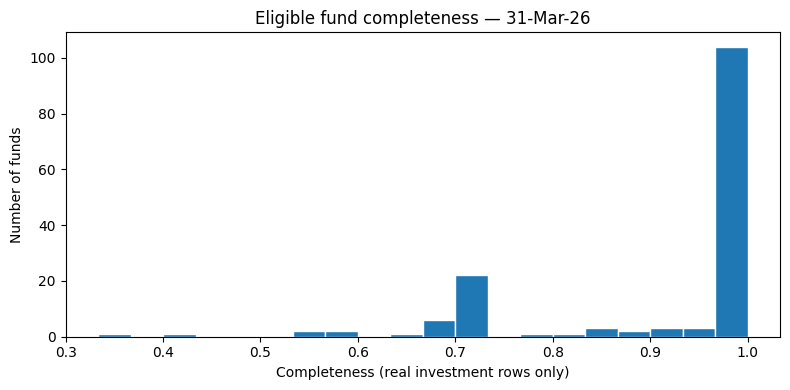


Top 10 by completeness:


,Fund Allocator ID,completeness,n_real_investments,Investment Manager Allocator ID,Type of Investment,wind_down_flag
0,Affdff0,1.0,12,A7dd292,Private Company,False
1,Ab89eda,1.0,26,A619a99,Private Company,False
2,A680edc,1.0,16,Aded344,Private Company,False
3,Ab781b9,1.0,14,A899074,Private Company,False
4,A67395e,1.0,8,A7970a7,Private Company,False
5,Ab7a076,1.0,6,A7b4b7c,Private Company,False
6,A64d20c,1.0,25,A041a39,Private Company,False
7,A60210b,1.0,11,A128c7a,Private Company,False
8,A5bfee3,1.0,14,A6a28da,Private Company,False
9,Ab7dccf,1.0,19,Aded344,Private Company,False


Bottom 10 by completeness:


,Fund Allocator ID,completeness,n_real_investments,Investment Manager Allocator ID,Type of Investment,wind_down_flag
142,A80b715,0.692857,20,A8d1733,Private Company,False
143,A65fb68,0.689441,23,Af0082f,Private Company,False
144,A583186,0.685714,10,A3e342a,Private Company,False
145,Ae3893b,0.642857,12,A02306d,Real Estate Asset,False
146,A29c2b9,0.571429,30,Aed3782,Private Company,False
147,A930514,0.571429,12,A109e0f,Private Company,False
148,Aa71003,0.555556,27,18be12,Real Estate Asset,False
149,A41fefa,0.542857,20,A8d1733,Private Company,False
150,Ae7bb35,0.413534,19,A5d1a01,Private Company,False
151,A87a21d,0.333333,9,A9fbabf,Private Company,False


In [5]:
eligible_ids = set(eligible_funds['Fund Allocator ID'])
eligible_real_rows = df_target_real[
    df_target_real['Fund Allocator ID'].isin(eligible_ids)
].copy()

missing_cols = [c for c in MANDATORY if c not in eligible_real_rows.columns]
if missing_cols:
    raise ValueError(f'Missing mandatory columns: {missing_cols}')


def fund_completeness(group: pd.DataFrame) -> float:
    subset = group[MANDATORY]
    denom = len(subset) * len(MANDATORY)
    if denom == 0:
        return np.nan
    return float(subset.notna().sum().sum() / denom)


scores = (
    eligible_real_rows.groupby('Fund Allocator ID')[MANDATORY]
    .apply(fund_completeness)
    .rename('completeness')
)

eligible_funds = eligible_funds.merge(
    scores.reset_index(), on='Fund Allocator ID', how='left'
)
eligible_funds = eligible_funds.sort_values('completeness', ascending=False).reset_index(drop=True)

print(f'Scored on: {MANDATORY}')
print(f'Eligible funds scored: {eligible_funds["completeness"].notna().sum()}')
print('\nCompleteness distribution:')
print(eligible_funds['completeness'].describe().to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(eligible_funds['completeness'].dropna(), bins=20, edgecolor='white')
ax.set_xlabel('Completeness (real investment rows only)')
ax.set_ylabel('Number of funds')
ax.set_title(f'Eligible fund completeness — {TARGET_AS_AT_DATE}')
plt.tight_layout()
plt.show()

print('\nTop 10 by completeness:')
display(eligible_funds.head(10)[
    ['Fund Allocator ID', 'completeness', 'n_real_investments',
     'Investment Manager Allocator ID', 'Type of Investment', 'wind_down_flag']
])
print('Bottom 10 by completeness:')
display(eligible_funds.tail(10)[
    ['Fund Allocator ID', 'completeness', 'n_real_investments',
     'Investment Manager Allocator ID', 'Type of Investment', 'wind_down_flag']
])

### 6. Diversity-constrained sampling (High / Low / Random)

Constraints:
1. **No duplicate Investment Manager** (hard; across High/Low/Random)
2. **Prefer distinct Type of Investment** (soft; within group; relax if needed)
3. **Size spread**: within-group candidate vs selected median ratio <= 10x (soft)
4. **Deprioritize wind-downs**: `wind_down_flag=True` moved to the end of the candidate list

Implementation: build a score-ordered shortlist under the hard constraint, then walk **completeness tiers** — within each tier prefer type/size diversity, backfill same-tier deferred funds, then move to a worse tier. Soft constraints are within-group only so High stays high-scoring and Low is not pulled toward high-scoring rare types.

In [6]:
def _size_ok(candidate_value, selected_values, ratio_max=SIZE_RATIO_MAX) -> bool:
    if pd.isna(candidate_value) or candidate_value <= 0:
        return True  # no size info → do not block
    if not selected_values:
        return True
    med = float(np.median(selected_values))
    if med <= 0:
        return True
    ratio = max(candidate_value / med, med / candidate_value)
    return ratio <= ratio_max


def select_diverse(
    candidates: pd.DataFrame,
    n: int,
    already_selected: pd.DataFrame | None = None,
    prefer_non_wind_down: bool = True,
) -> pd.DataFrame:
    """
    Score-first diversity selection:
    1) Keep candidate order (already sorted by completeness)
    2) Shortlist with HARD constraint only (unique Investment Manager across groups)
    3) Walk completeness tiers: within each tier, prefer soft type/size diversity,
       then fill deferred same-score funds before moving to a worse tier
    Soft type/size are within-group only — not inherited from already_selected.
    """
    already = (
        already_selected.copy()
        if already_selected is not None and len(already_selected)
        else pd.DataFrame(columns=candidates.columns)
    )
    used_ids = set(already['Fund Allocator ID']) if len(already) else set()
    used_managers = set(already['Investment Manager Allocator ID'].dropna()) if len(already) else set()

    pool = candidates[~candidates['Fund Allocator ID'].isin(used_ids)].copy()
    if prefer_non_wind_down and 'wind_down_flag' in pool.columns:
        pool = pd.concat([
            pool.loc[~pool['wind_down_flag']],
            pool.loc[pool['wind_down_flag']],
        ], ignore_index=True)

    # Shortlist: always include the entire top completeness tier (unique managers),
    # then continue until n * SHORTLIST_FACTOR so rare types at the same score are visible.
    shortlist_rows = []
    shortlist_managers = set(used_managers)
    shortlist_n = max(n * SHORTLIST_FACTOR, n)
    top_comp = pool.iloc[0]['completeness'] if len(pool) else None
    for _, row in pool.iterrows():
        mgr = row.get('Investment Manager Allocator ID')
        if pd.notna(mgr) and mgr in shortlist_managers:
            continue
        in_top_tier = (top_comp is not None and row['completeness'] == top_comp)
        if (not in_top_tier) and len(shortlist_rows) >= shortlist_n:
            break
        shortlist_rows.append(row)
        if pd.notna(mgr):
            shortlist_managers.add(mgr)
    shortlist = pd.DataFrame(shortlist_rows) if shortlist_rows else pd.DataFrame(columns=pool.columns)
    if shortlist.empty:
        return pd.DataFrame(columns=candidates.columns)

    selected_rows = []
    used_types: set = set()
    selected_sizes: list = []

    def soft_ok(row) -> bool:
        toi_val = row.get('Type of Investment')
        if pd.notna(toi_val) and toi_val in used_types:
            return False
        size_val = row.get('portfolio_total_value')
        if not _size_ok(size_val, selected_sizes):
            return False
        return True

    def commit(row):
        selected_rows.append(row)
        toi_val = row.get('Type of Investment')
        size_val = row.get('portfolio_total_value')
        if pd.notna(toi_val):
            used_types.add(toi_val)
        if pd.notna(size_val) and size_val > 0:
            selected_sizes.append(float(size_val))

    # Preserve score order of tiers as they appear in shortlist
    for comp_value in shortlist['completeness'].drop_duplicates().tolist():
        if len(selected_rows) >= n:
            break
        tier = shortlist.loc[shortlist['completeness'] == comp_value]
        deferred = []
        for _, row in tier.iterrows():
            if len(selected_rows) >= n:
                break
            if soft_ok(row):
                commit(row)
            else:
                deferred.append(row)
        for row in deferred:
            if len(selected_rows) >= n:
                break
            commit(row)

    if not selected_rows:
        return pd.DataFrame(columns=candidates.columns)
    return pd.DataFrame(selected_rows).reset_index(drop=True)


# --- High / Low ---
high_candidates = eligible_funds.sort_values(
    ['completeness', 'n_real_investments'], ascending=[False, False]
).reset_index(drop=True)
low_candidates = eligible_funds.sort_values(
    ['completeness', 'n_real_investments'], ascending=[True, False]
).reset_index(drop=True)

high_sample = select_diverse(high_candidates, N_HIGH)
high_sample['sample_group'] = 'high'

low_sample = select_diverse(low_candidates, N_LOW, already_selected=high_sample)
low_sample['sample_group'] = 'low'

# --- Random from mid-band (25th–75th), expand if needed ---
already = pd.concat([high_sample, low_sample], ignore_index=True)
remaining = eligible_funds[
    ~eligible_funds['Fund Allocator ID'].isin(already['Fund Allocator ID'])
].copy()

q25, q75 = remaining['completeness'].quantile([0.25, 0.75])
bands = [
    (q25, q75, '25-75'),
    (remaining['completeness'].quantile(0.10), remaining['completeness'].quantile(0.90), '10-90'),
    (remaining['completeness'].min(), remaining['completeness'].max(), 'all'),
]

random_sample = pd.DataFrame(columns=list(eligible_funds.columns) + ['sample_group'])
rng = np.random.default_rng(RANDOM_SEED)

for lo, hi, label in bands:
    band = remaining[
        (remaining['completeness'] >= lo) & (remaining['completeness'] <= hi)
    ].copy()
    if band.empty:
        continue
    order = rng.permutation(len(band))
    band = band.iloc[order].reset_index(drop=True)
    picked = select_diverse(band, N_RANDOM, already_selected=already)
    if len(picked) >= N_RANDOM or label == 'all':
        random_sample = picked.copy()
        random_sample['sample_group'] = 'random'
        print(f'Random band used: {label} (n_candidates={len(band)}, picked={len(picked)})')
        break

samples = pd.concat([high_sample, low_sample, random_sample], ignore_index=True)

print(f'\nSelected: high={len(high_sample)}, low={len(low_sample)}, random={len(random_sample)}')
print(f'Total unique managers: {samples["Investment Manager Allocator ID"].nunique()} / {len(samples)}')
display(samples[
    ['sample_group', 'Fund Allocator ID', 'completeness', 'n_real_investments',
     'Investment Manager Allocator ID', 'Type of Investment',
     'portfolio_total_value', 'wind_down_flag']
])

Random band used: 25-75 (n_candidates=105, picked=5)

Selected: high=6, low=6, random=5
Total unique managers: 17 / 17


,sample_group,Fund Allocator ID,completeness,n_real_investments,Investment Manager Allocator ID,Type of Investment,portfolio_total_value,wind_down_flag
0,high,Af8d59f,1.000000,29,A026529,Private Company,4.737193e+09,False
1,high,A4f0eca,1.000000,21,A2d789a,Public Company,2.453409e+09,False
2,high,Ab1beeb,1.000000,9,A6a2191,Real Estate Asset,4.603260e+08,False
3,high,A2a9ea5,1.000000,28,A041a39,Private Company,5.661139e+09,False
4,high,Abb96b2,1.000000,27,Ab02df9,Private Company,1.446564e+09,False
5,high,A396ea8,1.000000,27,Aded344,Private Company,1.363500e+09,False
6,low,A87a21d,0.333333,9,A9fbabf,Private Company,NaN,False
7,low,Ae7bb35,0.413534,19,A5d1a01,Private Company,2.326747e+08,False
8,low,A41fefa,0.542857,20,A8d1733,Private Company,NaN,False
9,low,Aa71003,0.555556,27,18be12,Real Estate Asset,NaN,False


### 7. Export results and validation checks

In [7]:
export_cols = [
    'sample_group', 'Fund Allocator ID', 'completeness', 'n_real_investments',
    'Investment Manager Allocator ID', 'Type of Investment',
    'portfolio_total_value', 'wind_down_flag',
]

samples_out = samples[export_cols].copy()
samples_out.to_csv('pdf_validation_samples.csv', index=False)

eligible_out = eligible_funds.sort_values('completeness', ascending=False).copy()
eligible_out.to_csv('eligible_funds_scored.csv', index=False)

print('Wrote pdf_validation_samples.csv')
print('Wrote eligible_funds_scored.csv')

# Per-group diagnostics
print('\n--- Per-group diagnostics ---')
for group, g in samples_out.groupby('sample_group', sort=False):
    print(
        f"{group:6s}: n={len(g)}, "
        f"completeness=[{g['completeness'].min():.1%}, {g['completeness'].max():.1%}], "
        f"investments=[{g['n_real_investments'].min()}, {g['n_real_investments'].max()}], "
        f"managers={g['Investment Manager Allocator ID'].nunique()}, "
        f"wind_down={int(g['wind_down_flag'].sum())}"
    )

# Validation checks
print('\n--- Validation checks ---')
ok_range = samples_out['n_real_investments'].between(MIN_INVESTMENTS, MAX_INVESTMENTS).all()
ok_count = len(samples_out) == (N_HIGH + N_LOW + N_RANDOM)
ok_no_single = (samples_out['n_real_investments'] > 1).all()
dup_mgr = int(samples_out['Investment Manager Allocator ID'].duplicated().sum())
ok_ids = samples_out['Fund Allocator ID'].is_unique

print(f'All samples have n_real in [{MIN_INVESTMENTS}, {MAX_INVESTMENTS}]: {ok_range}')
print(f'Total sample rows == {N_HIGH}+{N_LOW}+{N_RANDOM}: {ok_count} (got {len(samples_out)})')
print(f'No single-company samples: {ok_no_single}')
print(f'Unique Fund IDs: {ok_ids}')
print(f'Duplicate managers across all samples: {dup_mgr} (0 is ideal)')

assert ok_range, 'Found sample outside investment range'
assert ok_count, f'Expected {N_HIGH + N_LOW + N_RANDOM} samples'
assert ok_ids, 'Duplicate Fund Allocator IDs in samples'
assert ok_no_single, 'Found single-investment sample'
print('\nAll assertions passed.')

Wrote pdf_validation_samples.csv
Wrote eligible_funds_scored.csv

--- Per-group diagnostics ---
high  : n=6, completeness=[100.0%, 100.0%], investments=[9, 29], managers=6, wind_down=0
low   : n=6, completeness=[33.3%, 57.1%], investments=[9, 30], managers=6, wind_down=0
random: n=5, completeness=[100.0%, 100.0%], investments=[8, 18], managers=5, wind_down=0

--- Validation checks ---
All samples have n_real in [6, 30]: True
Total sample rows == 6+6+5: True (got 17)
No single-company samples: True
Unique Fund IDs: True
Duplicate managers across all samples: 0 (0 is ideal)

All assertions passed.


### Method note 

| Original filter | Improved filter |
|---|---|
| Rank by fill rate first | First require a normal multi-asset fund |
| Mix all quarters | Use the PDF-aligned reporting date |
| Score all rows | Score real investment rows only |
| No investment-count limit | Require at least 6 real investments (and <= 30) |
| Single-company funds can rank #1 | Single-company funds are excluded |
| Low scores can come from cash/liabilities | Low scores more likely reflect true missing info |

**One-liner:** the original algorithm describes field fill rates across the CSV, but it is not suitable for picking PDF validation samples — it does not control fund structure, real investment count, or non-investment rows. The improvement is not just swapping IDs; it first builds a comparable multi-asset pool, then compares completeness inside that pool.